Using device: cpu
Pretrained U-Shape Transformer loaded successfully!
Input shape: torch.Size([1, 3, 256, 256])


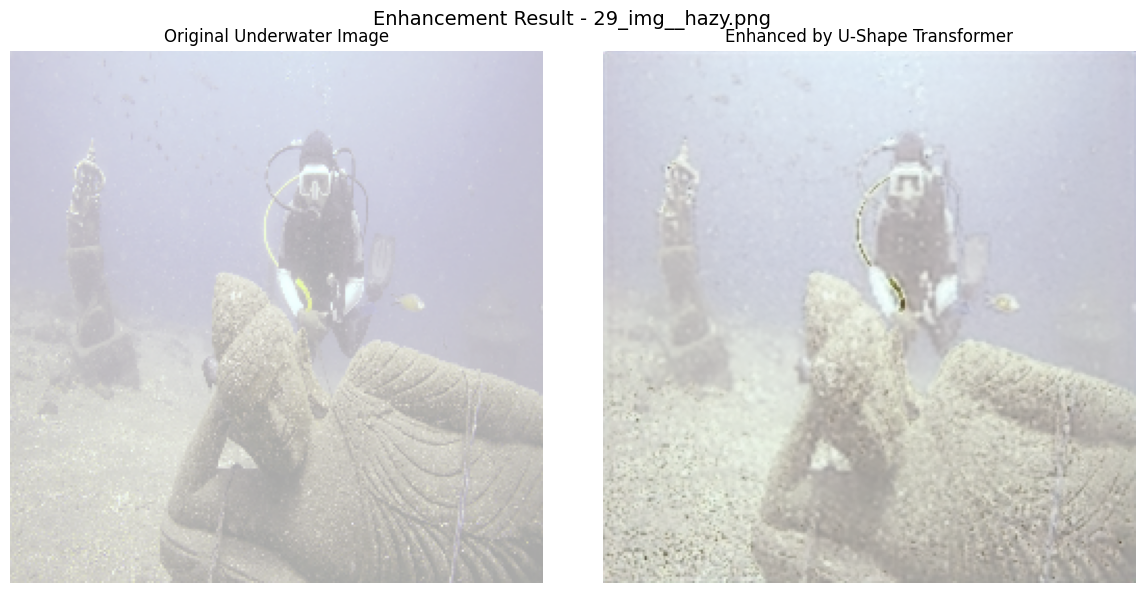

Enhanced image saved to: ./test/output\enhanced_29_img__hazy.png


In [9]:
# ===================== Single Image Enhancement + Plot =====================
# Run this in one Jupyter cell after setting up the environment and model files

import os
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.utils import save_image
from net.Ushape_Trans import Generator   # <-- Make sure this import works (from repo's net folder)

# --------------------- Settings ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to your single input image (change this!)
input_image_path = r"Y:\2025-2026\NEW DEV\JAN 2026\TK206833 -Adaptive Qualityaware underwater image enhancement using multiscale fusion\CODE\Backend\archive (2)\degraded_images\hazy\29_img__hazy.png"

# Path to pretrained model (from repo: saved_models/G/generator_*.pth)
model_path = r"Y:\2025-2026\NEW DEV\JAN 2026\TK206833 -Adaptive Qualityaware underwater image enhancement using multiscale fusion\CODE\front end\Front end\saved_models\saved_models\G\generator_795.pth"   # ← Use the exact filename you downloaded

# Desired resize size (model trained on 256×256)
IMG_SIZE = 256

# --------------------- Load Model ---------------------
generator = Generator().to(device)
generator.load_state_dict(torch.load(model_path, map_location=device))
generator.eval()
print("Pretrained U-Shape Transformer loaded successfully!")

# --------------------- Load & Preprocess Single Image ---------------------
img = cv2.imread(input_image_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {input_image_path}")

# Convert BGR → RGB and resize
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

# To tensor: HWC → CHW, [0,255] → [0,1]
img_tensor = torch.from_numpy(img_resized.astype(np.float32)).permute(2, 0, 1).unsqueeze(0) / 255.0
img_tensor = img_tensor.to(device)

print(f"Input shape: {img_tensor.shape}")

# --------------------- Inference ---------------------
with torch.no_grad():
    # Model outputs a list of multi-scale predictions; we take the final one (index 3)
    outputs = generator(img_tensor)
    enhanced = outputs[3]   # final enhanced output

# Clamp to valid range and prepare for display/save
enhanced = enhanced.clamp(0, 1)

# --------------------- Display Side-by-Side ---------------------
# Convert tensors back to numpy for plotting
original_np  = img_resized.astype(np.uint8)
enhanced_np  = (enhanced[0].cpu().permute(1, 2, 0).numpy() * 255).astype(np.uint8)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(original_np)
axes[0].set_title("Original Underwater Image")
axes[0].axis("off")

axes[1].imshow(enhanced_np)
axes[1].set_title("Enhanced by U-Shape Transformer")
axes[1].axis("off")

plt.suptitle(f"Enhancement Result - {os.path.basename(input_image_path)}", fontsize=14)
plt.tight_layout()
plt.show()

# Optional: Save the enhanced image
output_dir = "./test/output"
os.makedirs(output_dir, exist_ok=True)
save_path = os.path.join(output_dir, f"enhanced_{os.path.basename(input_image_path)}")
save_image(enhanced, save_path, normalize=True)
print(f"Enhanced image saved to: {save_path}")